In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

ucsc_cse_144_spring_2026_final_project_path = kagglehub.competition_download('ucsc-cse-144-spring-2026-final-project')

print('Data source import complete.')


100%|██████████| 120M/120M [00:01<00:00, 78.7MB/s]

Extracting files...


Data source import complete.


In [ ]:
# Imports and Setup
import os, random
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, models
from torchvision.transforms import v2 as tfv2
from torch.utils.data import DataLoader, random_split

device =  torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=42):
    ''' For reproducible results across runs '''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

In [ ]:
# Load Training/Validation Data, transform, normalize, augment

data_dir = ucsc_cse_144_spring_2026_final_project_path + '/'
batch_size = 128
num_workers = 0 # for reproducibility
train_validation_ratio = 0.2
transforms = tfv2.Compose([
    tfv2.ToTensor(),
    tfv2.Resize((256,256), interpolation=tfv2.InterpolationMode.BILINEAR), # as reccomended by vit_b_16 pytorch documentation
    tfv2.CenterCrop(224),
    # tfv2.RandomHorizontalFlip(), # augment data later
    # tfv2.RandomVerticalFlip(),
    tfv2.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
])

train_full = datasets.ImageFolder(root=data_dir+'train/', transform=transforms)
train_data, val_data = random_split(train_full, [1-train_validation_ratio, train_validation_ratio])
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

print("train/val:", len(train_data), len(val_data))

train/val: 864 215


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [ ]:
# Load pre-trained models

from torch.nn.modules import pooling
from torch.nn.modules.pooling import MaxUnpool2d

# using pre-trained model: vit b 16
base_model = models.vit_b_16(weights='DEFAULT')

# freeze layers
for param in base_model.parameters():
    param.requires_grad = False

num_ftrs = base_model.heads.head.in_features

In [ ]:
print(base_model)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
# Rebuilding model
num_classes= 100
# fix last layer for now
base_model.heads = nn.Sequential(nn.Dropout(p=0.3, inplace=True), # Hyperparameters: p=0.3
                                        nn.Linear(in_features=num_ftrs, out_features=num_classes) # output resized to fit our dataset
                                        )

base_model = base_model.to(device)

In [ ]:
# Load optimizers and criterion
import torch.optim as optim
optimizer = optim.Adam(base_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss() # cross entropy loss for classification

In [ ]:
# Functions called for Training

def accuracy(loader, model):
    model.eval()
    correct = 0
    total = 0
    for data, label in loader:
        data, label = data.to(device), label.to(device)
        output = model(data)
        prediction=output.argmax(1)
        total += label.size(0)
        correct += prediction.eq(label.view_as(prediction)).sum().item()

    return 100 * correct / total

def run_one_epoch(loader, model):
    model.train()
    total_loss = 0.0

    for data, label in loader:
        data, label = data.to(device), label.to(device)
        optimizer.zero_grad() # reset optimizer gradients
        output = model(data)
        loss = criterion(output, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    acc = accuracy(loader, model)
    return total_loss / len(loader), acc


In [ ]:
# Validation Functions

def validate(loader, model):
    model.eval()
    total_loss = 0.0

    for data, label in loader:
        data, label = data.to(device), label.to(device)
        output = model(data)
        loss = criterion(output, label)
        total_loss += loss.item()

    acc = accuracy(loader, model)
    return total_loss / len(loader), acc

In [ ]:
# Training and testing
num_epochs = 30
train_losses, train_accs = [], []
test_losses, test_accs  = [], []
val_losses, val_accs = [], []
best_val_acc = 0.0
best_epoch = -1
ckpt_path = "/content/drive/MyDrive/cse144_final_project_checkpoints/best_vit_b_16"

for epoch in range(num_epochs):
    train_loss, train_acc = run_one_epoch(loader=train_loader, model=base_model)
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    val_loss, val_acc = validate(loader=val_loader,model=base_model)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch ({epoch})- Train Loss: {train_loss}, Train Acc: {train_acc}, Val Loss: {val_loss}, Val Acc: {val_acc}")

    if best_val_acc < val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        torch.save({'model_state_dict':base_model.state_dict(), 'epoch':epoch}, ckpt_path)

Epoch (0)- Train Loss: 4.6755691937037875, Train Acc: 1.1574074074074074, Val Loss: 4.677819490432739, Val Acc: 0.9302325581395349
Epoch (1)- Train Loss: 4.678683962140765, Train Acc: 1.1574074074074074, Val Loss: 4.677819490432739, Val Acc: 0.9302325581395349
Epoch (2)- Train Loss: 4.671467849186489, Train Acc: 1.1574074074074074, Val Loss: 4.677819490432739, Val Acc: 0.9302325581395349
Epoch (3)- Train Loss: 4.687675816672189, Train Acc: 1.1574074074074074, Val Loss: 4.677819490432739, Val Acc: 0.9302325581395349
Epoch (4)- Train Loss: 4.672326701028006, Train Acc: 1.1574074074074074, Val Loss: 4.677819490432739, Val Acc: 0.9302325581395349
Epoch (5)- Train Loss: 4.670050825391497, Train Acc: 1.1574074074074074, Val Loss: 4.677819490432739, Val Acc: 0.9302325581395349
Epoch (6)- Train Loss: 4.662728105272565, Train Acc: 1.1574074074074074, Val Loss: 4.677819490432739, Val Acc: 0.9302325581395349
Epoch (7)- Train Loss: 4.666111060551235, Train Acc: 1.1574074074074074, Val Loss: 4.6778

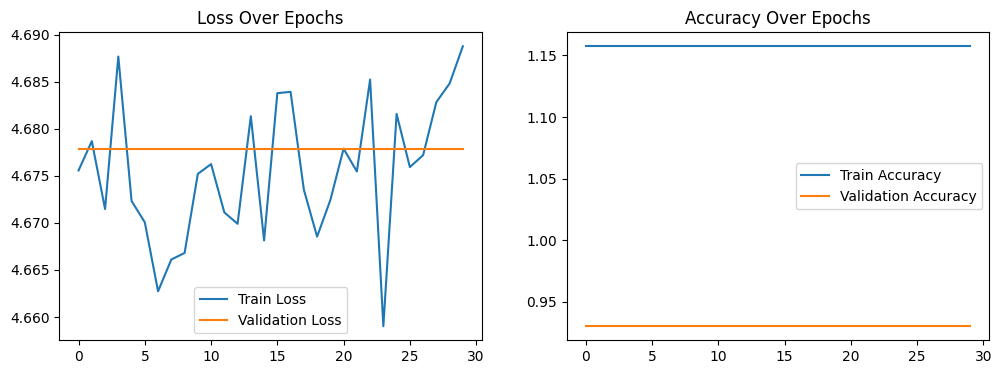

In [ ]:
# Plot loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Loss Over Epochs')
plt.legend()

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.legend()

plt.show()

In [ ]:
# Testing

import pandas as pd

# save as .csv file with imgID | class
state_dict = torch.load(ckpt_path)['model_state_dict']
base_model.load_state_dict(state_dict)


<All keys matched successfully>